In [ ]:
# Load the AG News dataset from Hugging Face
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

In [ ]:
# Shuffle the training dataset and select random 5000 samples, then extract the text data
dataset = dataset['train'].shuffle(seed=42).select(range(5000))
texts = dataset["text"]

In [ ]:
# Vectorize the text data using TF-IDF with a maximum of 5000 features and English stop words (is, and, this)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(texts)

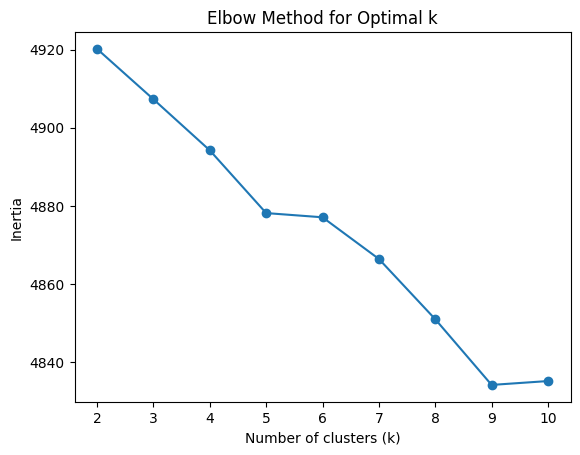

In [ ]:
# Use the Elbow method to determine the optimal number of clusters by plotting inertia for k from 2 to 10
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [ ]:
# Set the number of clusters to 5 based on the Elbow method
k = 5

In [ ]:
# Perform K-Means clustering with 5 clusters and predict cluster labels
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X)

In [ ]:
# Add the cluster labels as a new column to the dataset
dataset = dataset.add_column("cluster", clusters.tolist())

Flattening the indices:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
# Extract and print the top 10 terms for each cluster based on the centroids
import numpy as np

terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {top_terms}")

Cluster 0: ['percent', 'profit', 'sales', 'quarter', 'reuters', 'peoplesoft', 'oracle', 'dollar', 'year', 'said']
Cluster 1: ['microsoft', 'search', 'windows', 'google', 'xp', 'desktop', 'software', 'new', 'web', 'internet']
Cluster 2: ['ap', 'president', 'reuters', 'new', 'bush', 'said', 'year', 'election', 'space', 'afp']
Cluster 3: ['company', 'million', 'new', 'said', 'mobile', 'wireless', 'deal', 'phone', 'corp', 'ibm']
Cluster 4: ['quot', '39', 'said', 'says', 'new', 'microsoft', 'internet', 'red', 'world', 'intel']
Cluster 5: ['39', 'oil', 'prices', 'new', 'world', 'stocks', 'said', 'monday', 'year', 'china']
Cluster 6: ['game', 'win', 'season', '39', 'team', 'new', 'victory', 'cup', 'night', 'lead']
Cluster 7: ['gt', 'lt', 'fullquote', 'reuters', 'http', 'href', 'www', 'ticker', 'stocks', 'quickinfo']
Cluster 8: ['india', 'pakistan', 'peace', 'darfur', 'talks', 'sudan', 'minister', 'prime', 'kashmir', 'region']
Cluster 9: ['iraq', 'baghdad', 'killed', 'gaza', 'iraqi', 'reuters'

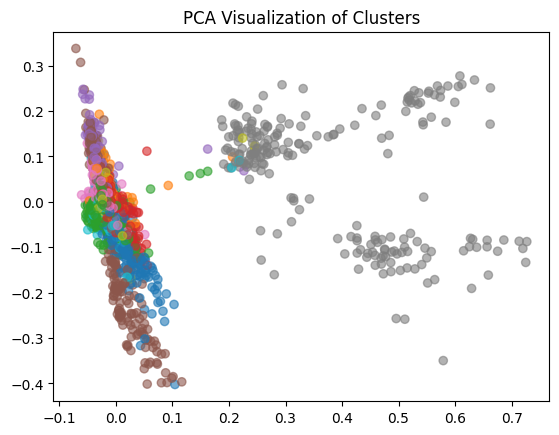

In [ ]:
# Reduce dimensionality to 2D using PCA and visualize the clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=clusters,
    cmap="tab10",
    alpha=0.6
)
plt.title("PCA Visualization of Clusters")
plt.show()

In [ ]:
# Split the data into training and testing sets for evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, clusters, test_size=0.2, random_state=42, stratify=clusters
)

In [ ]:
# Train a Logistic Regression classifier on the training data
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Evaluate the classifier on the test data and print the classification report
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.68      0.81        66
           1       1.00      0.63      0.78        41
           2       0.76      1.00      0.86       260
           3       0.88      0.90      0.89       172
           4       1.00      0.87      0.93        31
           5       0.87      0.84      0.86       131
           6       0.93      0.89      0.91       163
           7       1.00      0.95      0.98        44
           8       1.00      0.50      0.67        30
           9       1.00      0.74      0.85        62

    accuracy                           0.87      1000
   macro avg       0.94      0.80      0.85      1000
weighted avg       0.89      0.87      0.87      1000

